### **Data Collecting**

In [23]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
import warnings

In [24]:
warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', None)
pd.set_option('display.float_format', lambda x: '%.2f' % x)

In [25]:
df_raw = pd.read_csv('../data/raw/sales_data.csv')
df_raw.head()

,Date,Store ID,Product ID,Category,Region,Inventory Level,Units Sold,Units Ordered,Price,Discount,Weather Condition,Promotion,Competitor Pricing,Seasonality,Epidemic,Demand
0,2022-01-01,S001,P0001,Electronics,North,195,102,252,72.72,5,Snowy,0,85.73,Winter,0,115
1,2022-01-01,S001,P0002,Clothing,North,117,117,249,80.16,15,Snowy,1,92.02,Winter,0,229
2,2022-01-01,S001,P0003,Clothing,North,247,114,612,62.94,10,Snowy,1,60.08,Winter,0,157
3,2022-01-01,S001,P0004,Electronics,North,139,45,102,87.63,10,Snowy,0,85.19,Winter,0,52
4,2022-01-01,S001,P0005,Groceries,North,152,65,271,54.41,0,Snowy,0,51.63,Winter,0,59


In [26]:
df_raw.info()

<class 'pandas.DataFrame'>
RangeIndex: 76000 entries, 0 to 75999
Data columns (total 16 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Date                76000 non-null  str    
 1   Store ID            76000 non-null  str    
 2   Product ID          76000 non-null  str    
 3   Category            76000 non-null  str    
 4   Region              76000 non-null  str    
 5   Inventory Level     76000 non-null  int64  
 6   Units Sold          76000 non-null  int64  
 7   Units Ordered       76000 non-null  int64  
 8   Price               76000 non-null  float64
 9   Discount            76000 non-null  int64  
 10  Weather Condition   76000 non-null  str    
 11  Promotion           76000 non-null  int64  
 12  Competitor Pricing  76000 non-null  float64
 13  Seasonality         76000 non-null  str    
 14  Epidemic            76000 non-null  int64  
 15  Demand              76000 non-null  int64  
dtypes: float64(2), 

In [27]:
df_raw.isnull().sum()

Date                  0
Store ID              0
Product ID            0
Category              0
Region                0
Inventory Level       0
Units Sold            0
Units Ordered         0
Price                 0
Discount              0
Weather Condition     0
Promotion             0
Competitor Pricing    0
Seasonality           0
Epidemic              0
Demand                0
dtype: int64

In [28]:
df_raw.select_dtypes(include='object').nunique()

Date                 760
Store ID               5
Product ID            20
Category               5
Region                 4
Weather Condition      4
Seasonality            4
dtype: int64

### **Data Wrangling**

In [29]:
df_raw['Date'] = pd.to_datetime(df_raw['Date'])
df_raw = df_raw.sort_values(by=['Date', 'Store ID', 'Product ID']).reset_index(drop=True)

In [30]:
df_raw['Day'] = df_raw['Date'].dt.day
df_raw['Month'] = df_raw['Date'].dt.month
df_raw['DayOfWeek'] = df_raw['Date'].dt.dayofweek
df_raw['IsWeekend'] = df_raw['DayOfWeek'].apply(lambda x: 1 if x >= 5 else 0)
df_raw['Quarter'] = df_raw['Date'].dt.quarter

### **Exploratory Data**

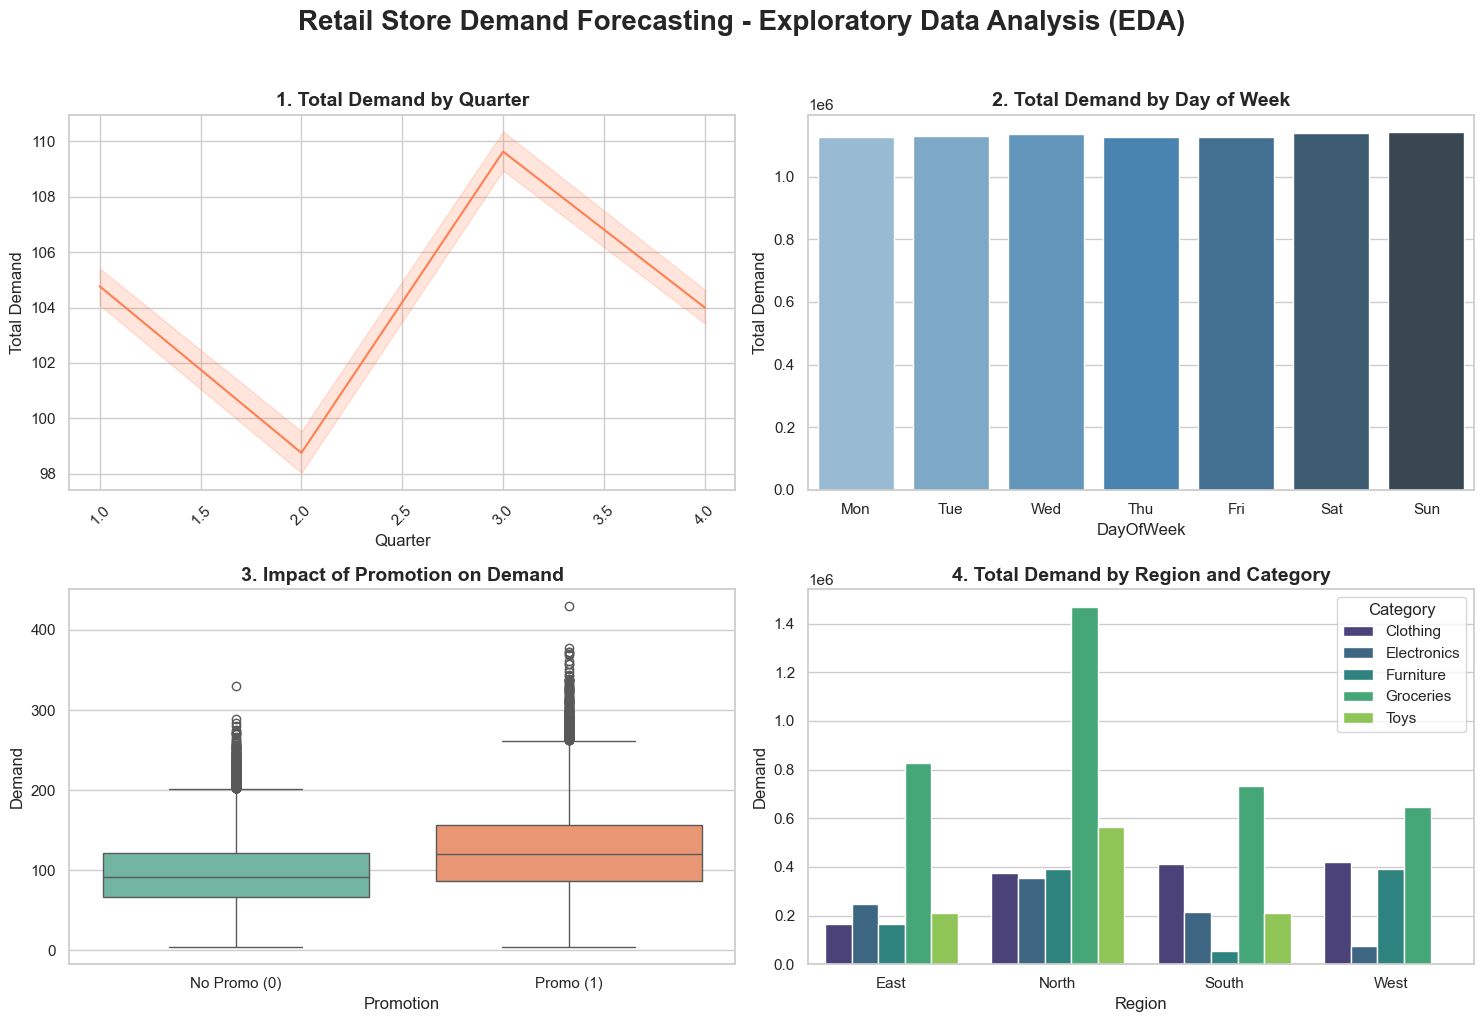

In [31]:
sns.set_theme(style="whitegrid", palette="muted")
fig, axes = plt.subplots(2, 2, figsize=(15, 10))

# 1. Total Demand by Quarter
sns.lineplot(data=df_raw, x='Quarter', y='Demand', ax=axes[0, 0], color='coral')
axes[0, 0].set_title('1. Total Demand by Quarter', fontsize=14, fontweight='bold')
axes[0, 0].set_ylabel('Total Demand')
axes[0, 0].set_xlabel('Quarter')
axes[0, 0].tick_params(axis='x', rotation=45) 

# 2. Total Demand by Day of Week
sns.barplot(data=df_raw, x='DayOfWeek', y='Demand', ax=axes[0, 1], estimator=sum, ci=None, palette='Blues_d')
axes[0, 1].set_title('2. Total Demand by Day of Week', fontsize=14, fontweight='bold')
axes[0, 1].set_xticklabels(['Mon', 'Tue', 'Wed', 'Thu', 'Fri', 'Sat', 'Sun'])
axes[0, 1].set_ylabel('Total Demand')

# 3. Impact of Promotion on Demand
sns.boxplot(data=df_raw, x='Promotion', y='Demand', ax=axes[1, 0], palette='Set2')
axes[1, 0].set_title('3. Impact of Promotion on Demand', fontsize=14, fontweight='bold')
axes[1, 0].set_xticklabels(['No Promo (0)', 'Promo (1)'])

# 4. Total Demand by Region and Category
cat_region_demand = df_raw.groupby(['Region', 'Category'])['Demand'].sum().reset_index()

sns.barplot(data=cat_region_demand, x='Region', y='Demand', hue='Category', ax=axes[1, 1], palette='viridis')
axes[1, 1].set_title('4. Total Demand by Region and Category', fontsize=14, fontweight='bold')

fig.suptitle('Retail Store Demand Forecasting - Exploratory Data Analysis (EDA)', fontsize=20, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

In [32]:
corr_matrix =df_raw.corr(numeric_only=True)
demand_corr = corr_matrix['Demand'].sort_values(ascending=False)
print("Correlation of features with Demand:")
print(demand_corr)

Correlation of features with Demand:
Demand                1.00
Units Sold            0.83
Units Ordered         0.51
Promotion             0.28
Discount              0.22
Inventory Level       0.13
Month                 0.04
Quarter               0.02
DayOfWeek             0.01
IsWeekend             0.00
Day                  -0.02
Competitor Pricing   -0.02
Price                -0.02
Epidemic             -0.36
Name: Demand, dtype: float64


In [33]:
skewness = df_raw['Demand'].skew()
print(f"Skewness of Demand: {skewness:.2f}")

Skewness of Demand: 0.61


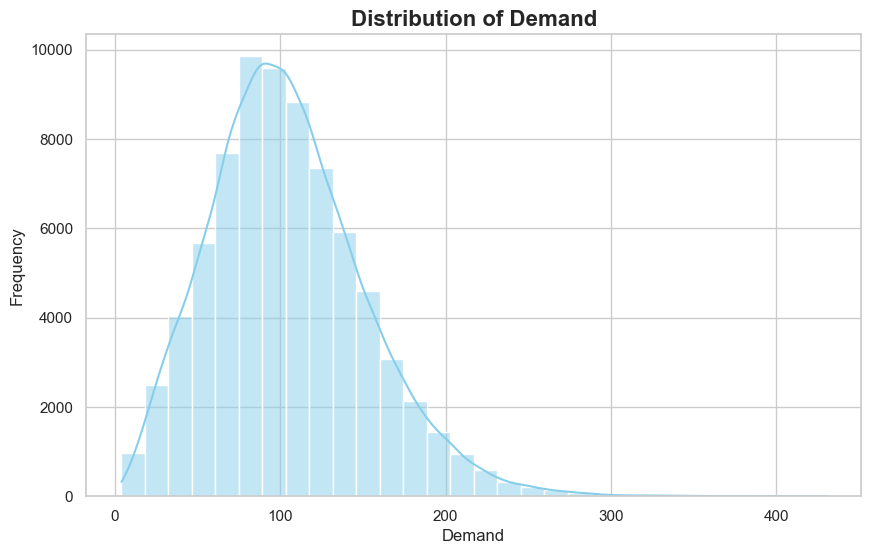

In [34]:
plt.figure(figsize=(10, 6))
sns.histplot(df_raw['Demand'], bins=30, kde=True, color='skyblue')
plt.title('Distribution of Demand', fontsize=16, fontweight='bold')
plt.xlabel('Demand')
plt.ylabel('Frequency')
plt.show()

### **Feature Engineering**

In [35]:
# Lag Features
df_raw['Demand_Lag_1'] = df_raw.groupby(['Store ID', 'Product ID'])['Demand'].shift(1)
df_raw['Demand_Lag_7'] = df_raw.groupby(['Store ID', 'Product ID'])['Demand'].shift(7)

# Rolling Mean
df_raw['Demand_Rolling_Mean_7'] = df_raw.groupby(['Store ID', 'Product ID'])['Demand'].transform(lambda x: x.rolling(window=7, min_periods=1).mean())

In [37]:
# drop Unit Sold and Unit Ordered
df_raw = df_raw.drop(columns=['Units Sold', 'Units Ordered'])

# drop rows with missing values
df_processed = df_raw.dropna().reset_index(drop=True)

In [38]:
df_processed.head()

,Date,Store ID,Product ID,Category,Region,Inventory Level,Price,Discount,Weather Condition,Promotion,Competitor Pricing,Seasonality,Epidemic,Demand,Day,Month,DayOfWeek,IsWeekend,Quarter,Demand_Lag_1,Demand_Lag_7,Demand_Rolling_Mean_7
0,2022-01-08,S001,P0001,Electronics,North,308,68.56,10,Snowy,1,80.99,Winter,0,113,8,1,5,1,1,87.00,115.00,105.57
1,2022-01-08,S001,P0002,Clothing,North,77,76.30,15,Snowy,1,90.66,Winter,0,208,8,1,5,1,1,94.00,229.00,133.43
2,2022-01-08,S001,P0003,Clothing,North,308,54.15,15,Snowy,1,58.19,Winter,0,142,8,1,5,1,1,71.00,157.00,120.00
3,2022-01-08,S001,P0004,Electronics,North,155,69.37,20,Snowy,1,78.42,Winter,0,36,8,1,5,1,1,57.00,52.00,59.00
4,2022-01-08,S001,P0005,Groceries,North,1293,53.57,5,Snowy,0,59.53,Winter,0,83,8,1,5,1,1,97.00,59.00,114.00


In [39]:
df_processed.info()

<class 'pandas.DataFrame'>
RangeIndex: 75300 entries, 0 to 75299
Data columns (total 22 columns):
 #   Column                 Non-Null Count  Dtype         
---  ------                 --------------  -----         
 0   Date                   75300 non-null  datetime64[us]
 1   Store ID               75300 non-null  str           
 2   Product ID             75300 non-null  str           
 3   Category               75300 non-null  str           
 4   Region                 75300 non-null  str           
 5   Inventory Level        75300 non-null  int64         
 6   Price                  75300 non-null  float64       
 7   Discount               75300 non-null  int64         
 8   Weather Condition      75300 non-null  str           
 9   Promotion              75300 non-null  int64         
 10  Competitor Pricing     75300 non-null  float64       
 11  Seasonality            75300 non-null  str           
 12  Epidemic               75300 non-null  int64         
 13  Demand      

### **Save Processed Data**

In [40]:
SAVE_PATH = '../data/processed/processed_sales_data.csv'
df_processed.to_csv(SAVE_PATH, index=False)
print(f"Processed data saved to: {SAVE_PATH}")

Processed data saved to: ../data/processed/processed_sales_data.csv
